In [ ]:
import os
import glob
import numpy as np
import cv2

class EuRoCDatasetLoader:
    """
    Loads the EuRoC MAV dataset (simulation version: images + IMU CSV).
    Directory structure example:
    vio_slam_project/data/mav0/
      ├── cam0/data/*.png
      ├── cam1/data/*.png
      └── imu0/data.csv
    """
    def __init__(self, root_dir: str):
        self.root_dir = root_dir
        self.cam_dirs = {
            'cam0': os.path.join(root_dir, 'cam0', 'data'),
            'cam1': os.path.join(root_dir, 'cam1', 'data'),
        }
        self.imu_file = os.path.join(root_dir, 'imu0', 'data.csv')

    def load_images(self, cam: str = 'cam0'):
        """
        Returns (timestamps, image_paths) - two lists of equal length
        - timestamps: list of int (ns)
        - image_paths: list of str
        """
        cam_dir = self.cam_dirs.get(cam)
        if cam_dir is None or not os.path.isdir(cam_dir):
            raise ValueError(f"Unknown or missing camera directory: {cam_dir}")
        # Sort by filename
        files = sorted(glob.glob(os.path.join(cam_dir, '*.png')))
        timestamps = [int(os.path.splitext(os.path.basename(f))[0]) for f in files]
        return timestamps, files

    def load_imu(self):
        """
        Reads imu0/data.csv, assumes each line format:
        timestamp [ns], gx, gy, gz, ax, ay, az
        Returns (timestamps, gyro, accel):
        - timestamps: numpy array (N,), dtype=int64
        - gyro: numpy array (N,3)
        - accel: numpy array (N,3)
        """

        if not os.path.isfile(self.imu_file):
            raise FileNotFoundError(f"IMU file not found: {self.imu_file}")
        # Use comma separator and skip comments
        data = np.loadtxt(self.imu_file, delimiter=',', comments='#')
        timestamps = data[:, 0].astype(np.int64)
        gyro       = data[:, 1:4]
        accel      = data[:, 4:7]
        return timestamps, gyro, accel


    def visualize_sample(self, cam: str = 'cam0', idx: int = 0):
        """
        Simple visualization of the idx-th frame, tests if loading works correctly
        """
        _, paths = self.load_images(cam)
        img = cv2.imread(paths[idx], cv2.IMREAD_GRAYSCALE)
        cv2.imshow(f"{cam} frame {idx}", img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

if __name__ == "__main__":
    # test
    loader = EuRoCDatasetLoader(root_dir="data/mav0")
    ts_img, img_paths = loader.load_images('cam0')
    ts_imu, gyro, accel = loader.load_imu()
    print(f"Loaded {len(ts_img)} images, {len(ts_imu)} IMU samples")


Loaded 3682 images, 36820 IMU samples


In [43]:
import os
import glob
import cv2
import numpy as np

class EuRoCDatasetLoader:
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.cam_dirs = {
            'cam0': os.path.join(root_dir, 'cam0', 'data'),
            'cam1': os.path.join(root_dir, 'cam1', 'data')
        }
        self.imu_file = os.path.join(root_dir, 'imu0', 'data.csv')

    def load_images(self, cam='cam0'):
        cam_dir = self.cam_dirs.get(cam)
        if cam_dir is None or not os.path.isdir(cam_dir):
            raise ValueError(f"Unknown or missing camera directory: {cam_dir}")
        files = sorted(glob.glob(os.path.join(cam_dir, '*.png')))
        timestamps = [int(os.path.basename(f).split('.')[0]) for f in files]
        return timestamps, files

    def load_imu(self):
        if not os.path.isfile(self.imu_file):
            raise ValueError(f"IMU file not found: {self.imu_file}")
        data = np.loadtxt(self.imu_file, delimiter=',', skiprows=1)
        timestamps = data[:, 0].astype(np.int64)
        gyro = data[:, 1:4]
        accel = data[:, 4:7]
        return timestamps, gyro, accel


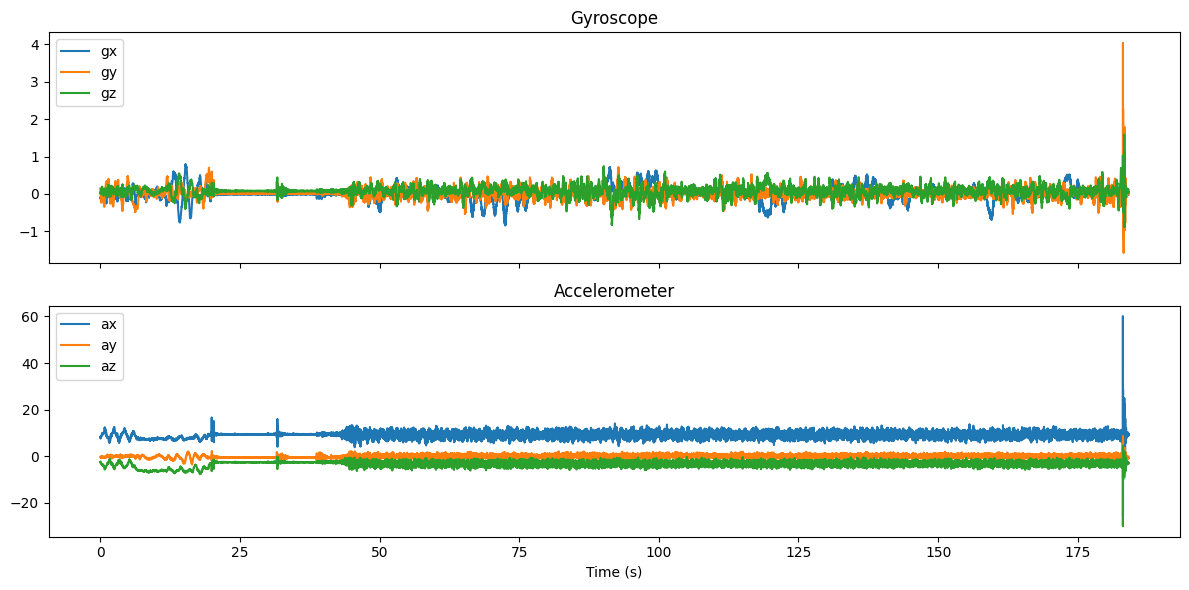

In [ ]:
import matplotlib.pyplot as plt

# visualize IMU
def visualize_imu(ts, gyro, accel):
    time_s = (ts - ts[0]) * 1e-9  # ns 

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    axs[0].plot(time_s, gyro[:, 0], label='gx')
    axs[0].plot(time_s, gyro[:, 1], label='gy')
    axs[0].plot(time_s, gyro[:, 2], label='gz')
    axs[0].set_title('Gyroscope')
    axs[0].legend()

    axs[1].plot(time_s, accel[:, 0], label='ax')
    axs[1].plot(time_s, accel[:, 1], label='ay')
    axs[1].plot(time_s, accel[:, 2], label='az')
    axs[1].set_title('Accelerometer')
    axs[1].set_xlabel('Time (s)')
    axs[1].legend()

    plt.tight_layout()
    plt.show()


visualize_imu(ts_imu, gyro, accel)


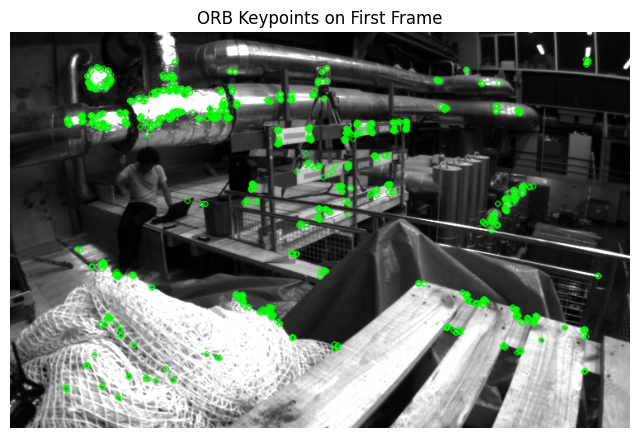

In [ ]:
def visualize_orb_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    orb = cv2.ORB_create(nfeatures=1000)
    keypoints = orb.detect(img, None)
    img_kp = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0))

    plt.figure(figsize=(8, 6))
    plt.title("ORB Keypoints on First Frame")
    plt.imshow(img_kp, cmap='gray')
    plt.axis('off')
    plt.show()

# example
visualize_orb_features(img_paths[0])


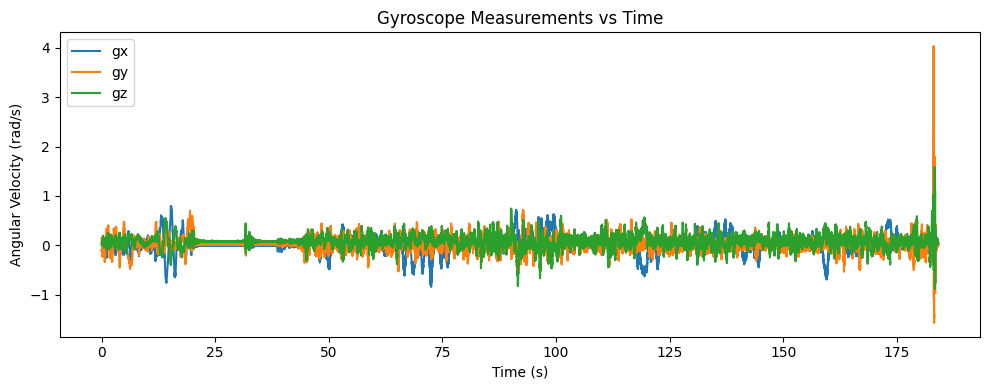

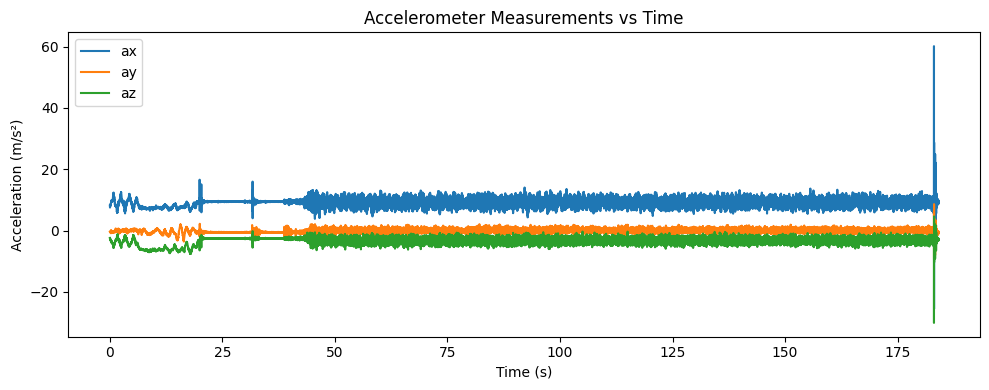

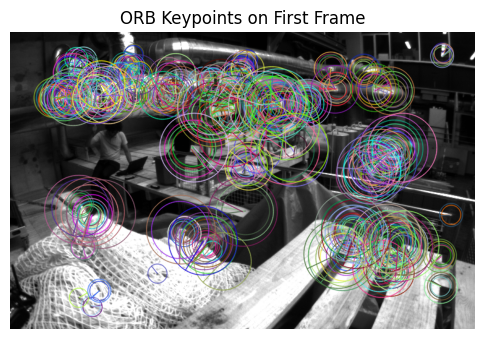

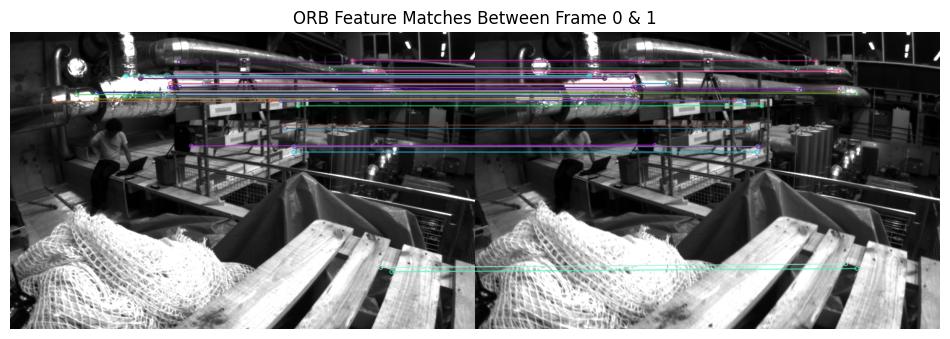

In [ ]:
# VIO-SLAM Unified Script
# Including: EuRoC data loading, IMU visualization, ORB feature detection and tracking

import os
import sys
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. Data Loader
# -----------------------------------------------------------------------------
class EuRoCDatasetLoader:
    """
    Loads the EuRoC MAV dataset (images + IMU CSV format)
    Directory structure:
      data/mav0/
        cam0/data/*.png
        cam1/data/*.png
        imu0/data.csv
    """
    def __init__(self, root_dir: str):
        self.root_dir = root_dir
        self.cam_dirs = {
            'cam0': os.path.join(root_dir, 'cam0', 'data'),
            'cam1': os.path.join(root_dir, 'cam1', 'data'),
        }
        self.imu_file = os.path.join(root_dir, 'imu0', 'data.csv')

    def load_images(self, cam: str = 'cam0'):
        cam_dir = self.cam_dirs.get(cam)
        if cam_dir is None or not os.path.isdir(cam_dir):
            raise ValueError(f"Missing camera directory: {cam_dir}")
        files = sorted(glob.glob(os.path.join(cam_dir, '*.png')))
        timestamps = np.array([int(os.path.splitext(os.path.basename(f))[0]) for f in files], dtype=np.int64)
        return timestamps, files

    def load_imu(self):
        if not os.path.isfile(self.imu_file):
            raise FileNotFoundError(f"IMU file not found: {self.imu_file}")
        data = np.loadtxt(self.imu_file, delimiter=',', comments='#')
        ts    = data[:, 0].astype(np.int64)
        gyro  = data[:, 1:4]
        accel = data[:, 4:7]
        return ts, gyro, accel

# -----------------------------------------------------------------------------
# 2. ORB Feature Tracking Class
# -----------------------------------------------------------------------------
class ORBTracker:
    def __init__(self, n_features: int = 1000):
        self.orb = cv2.ORB_create(nfeatures=n_features)
        self.bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    def detect_and_compute(self, img):
        kp, des = self.orb.detectAndCompute(img, None)
        return kp, des

    def match(self, des1, des2):
        matches = self.bf.match(des1, des2)
        return sorted(matches, key=lambda m: m.distance)

    def track(self, img1, img2, top_k: int = 200):
        kp1, des1 = self.detect_and_compute(img1)
        kp2, des2 = self.detect_and_compute(img2)
        matches   = self.match(des1, des2)[:top_k]
        pts1 = np.array([kp1[m.queryIdx].pt for m in matches], dtype=np.float32)
        pts2 = np.array([kp2[m.trainIdx].pt for m in matches], dtype=np.float32)
        return kp1, kp2, pts1, pts2, matches

    def draw_matches(self, img1, img2, kp1, kp2, matches, num: int = 50):
        return cv2.drawMatches(
            img1, kp1, img2, kp2,
            matches[:num], None,
            flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS
        )

# -----------------------------------------------------------------------------
# 3. Main Process: Load Data & Visualize
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    # 3.1 Initialize loader
    loader = EuRoCDatasetLoader(root_dir='data/mav0')

    # 3.2 Load IMU
    ts_imu, gyro, accel = loader.load_imu()
    time_s = (ts_imu - ts_imu[0]) * 1e-9  # 转为秒

    # 3.3 Plot gyroscope data
    plt.figure(figsize=(10,4))
    plt.plot(time_s, gyro[:,0], label='gx')
    plt.plot(time_s, gyro[:,1], label='gy')
    plt.plot(time_s, gyro[:,2], label='gz')
    plt.title('Gyroscope Measurements vs Time')
    plt.xlabel('Time (s)')
    plt.ylabel('Angular Velocity (rad/s)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3.4 Plot accelerometer data
    plt.figure(figsize=(10,4))
    plt.plot(time_s, accel[:,0], label='ax')
    plt.plot(time_s, accel[:,1], label='ay')
    plt.plot(time_s, accel[:,2], label='az')
    plt.title('Accelerometer Measurements vs Time')
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration (m/s²)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3.5 Load two image frames
    ts_img, img_paths = loader.load_images('cam0')
    img1 = cv2.imread(img_paths[0], cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img_paths[1], cv2.IMREAD_GRAYSCALE)

    # 3.6 ORB feature detection (visualize first frame)
    orb = cv2.ORB_create(nfeatures=500)
    kp, des = orb.detectAndCompute(img1, None)
    img_kp = cv2.drawKeypoints(img1, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    img_kp = cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img_kp)
    plt.title('ORB Keypoints on First Frame')
    plt.axis('off')
    plt.show()

    # 3.7 ORB feature tracking (visualize matches between two frames)
    tracker = ORBTracker(n_features=1000)
    kp1, kp2, pts1, pts2, matches = tracker.track(img1, img2, top_k=200)
    img_matches = tracker.draw_matches(img1, img2, kp1, kp2, matches, num=50)
    img_matches = cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,6))
    plt.imshow(img_matches)
    plt.title('ORB Feature Matches Between Frame 0 & 1')
    plt.axis('off')
    plt.show()


Preintegrated Δp: [ 0.00962655 -0.00052653 -0.01532386]
Preintegrated Δv: [ 0.34708521 -0.01986443 -0.56116754]
Preintegrated ΔR:
 [[ 0.99998816 -0.00234077  0.00426733]
 [ 0.0023201   0.99998559  0.00484148]
 [-0.0042786  -0.00483152  0.99997917]]


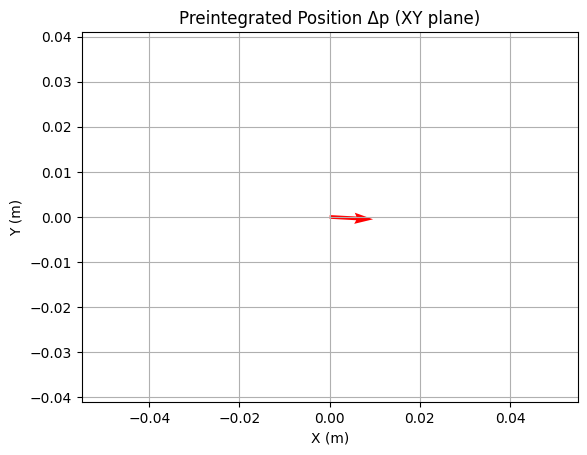

In [ ]:
# -----------------------------------------------------------------------------
# 3.a IMU Preintegration Module
# -----------------------------------------------------------------------------
import numpy as np
import scipy.spatial.transform

class IMUPreintegrator:
    """
    Mid-point method based IMU preintegration (no bias assumption)
    """
    def __init__(self):
        self.reset()

    def reset(self):
        self.delta_t = 0.0
        self.delta_R = np.eye(3)
        self.delta_v = np.zeros(3)
        self.delta_p = np.zeros(3)

    def integrate(self, dt_arr, omega_arr, acc_arr, g=np.array([0,0,-9.81])):
        """
        Args:
            dt_arr:    (N,) Time interval array, unit s
            omega_arr: (N,3) Gyroscope measurements, rad/s
            acc_arr:   (N,3) Accelerometer measurements, m/s^2
            g:         Gravity acceleration vector
        Returns:
            delta_p, delta_v, delta_R
        """
        self.reset()
        for dt, w, a in zip(dt_arr, omega_arr, acc_arr):
            # 1. Update rotation: mid-point method
            theta = w * dt
            dR = scipy.spatial.transform.Rotation.from_rotvec(theta).as_matrix()
            R_mid = self.delta_R if hasattr(dR, "__pow__") else self.delta_R
            self.delta_R = self.delta_R @ dR

            # 2. Update velocity
            a_world = self.delta_R @ a + g
            self.delta_v += a_world * dt

            # 3. Update position
            self.delta_p += self.delta_v * dt + 0.5 * a_world * dt**2

            self.delta_t += dt

        return self.delta_p, self.delta_v, self.delta_R

# -----------------------------------------------------------------------------
# 4. Main Process Extension: Using IMU Preintegration to estimate relative motion between two frames
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    

    # 4.1 Select two frame timestamps
    t0, t1 = ts_img[0], ts_img[1]
    # Find IMU data index range
    mask = (ts_imu >= t0) & (ts_imu < t1)
    imu_ts = ts_imu[mask] * 1e-9  # ns -> s
    imu_gyro = gyro[mask]
    imu_acc  = accel[mask]

    # 4.2 Calculate dt, angular velocity, acceleration arrays
    dt_arr    = np.diff(imu_ts)
    omega_arr = imu_gyro[:-1]
    acc_arr   = imu_acc[:-1]

    # 4.3 Preintegration
    preint = IMUPreintegrator()
    dp, dv, dR = preint.integrate(dt_arr, omega_arr, acc_arr)

    # 4.4 Print results
    print("Preintegrated Δp:", dp)
    print("Preintegrated Δv:", dv)
    print("Preintegrated ΔR:\n", dR)

    # 4.5 Visualize Δp vector
    plt.figure()
    plt.quiver(0, 0, dp[0], dp[1], angles='xy', scale_units='xy', scale=1, color='r')
    plt.title('Preintegrated Position Δp (XY plane)')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.axis('equal')
    plt.grid(True)
    plt.show()


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.2525e-35                                    3.47e-18    
`gtol` termination condition is satisfied.
Function evaluations 1, initial cost 1.2525e-35, final cost 1.2525e-35, first-order optimality 3.47e-18.


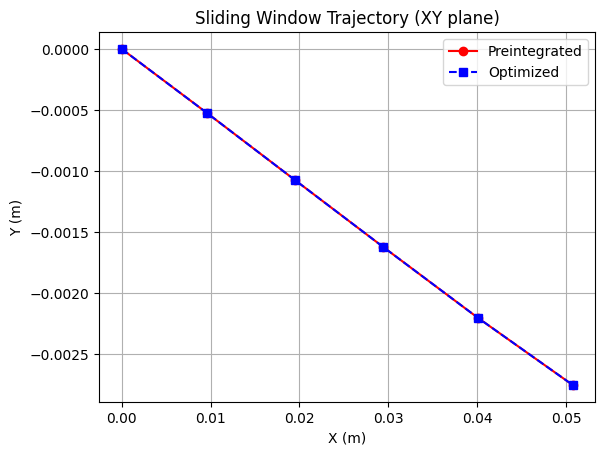

In [ ]:
# -----------------------------------------------------------------------------
# 5. IMU Preintegration + Sliding Window Optimization 
# -----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# ——— 5.1 Redefine IMUPreintegrator ———
import scipy.spatial.transform
class IMUPreintegrator:
    def __init__(self):
        self.reset()
    def reset(self):
        self.delta_t = 0.0
        self.delta_R = np.eye(3)
        self.delta_v = np.zeros(3)
        self.delta_p = np.zeros(3)
    def integrate(self, dt_arr, omega_arr, acc_arr, g=np.array([0,0,-9.81])):
        self.reset()
        for dt, w, a in zip(dt_arr, omega_arr, acc_arr):
            
            dR = scipy.spatial.transform.Rotation.from_rotvec(w*dt).as_matrix()
            self.delta_R = self.delta_R @ dR
            
            a_w = self.delta_R @ a + g
            self.delta_v += a_w * dt
            
            self.delta_p += self.delta_v * dt + 0.5 * a_w * dt**2
            self.delta_t += dt
        return self.delta_p.copy(), self.delta_v.copy(), self.delta_R.copy()

# ——— 5.2 Prepare window size & preintegration values ———
K = 5  # Use first 6 frames (0..5) for sliding window
dps = []
dRs = []
preint = IMUPreintegrator()
for i in range(1, K+1):
    t0, t1 = ts_img[i-1], ts_img[i]
    mask = (ts_imu >= t0) & (ts_imu < t1)
    ts_sec = ts_imu[mask] * 1e-9
    dt_arr    = np.diff(ts_sec)
    omega_arr = gyro[mask][:-1]
    acc_arr   = accel[mask][:-1]
    dp, dv, dR = preint.integrate(dt_arr, omega_arr, acc_arr)
    dps.append(dp)
    dRs.append(dR)

# ——— 5.3 Construct initial guess ———
p_init = np.zeros((K+1, 3))
theta_init = np.zeros(K+1)
for i in range(1, K+1):
    p_init[i] = p_init[i-1] + dps[i-1]
    # extract yaw
    R = dRs[i-1]
    yaw = np.arctan2(R[1,0], R[0,0])
    theta_init[i] = theta_init[i-1] + yaw

x0 = np.hstack([p_init.flatten(), theta_init])

# ——— 5.4 Define residuals ———
def residual(x):
    p = x[:3*(K+1)].reshape((K+1,3))
    theta = x[3*(K+1):]
    res = []
    for i in range(1, K+1):
        # 位置残差
        res.extend((p[i] - p[i-1] - dps[i-1]).tolist())
        # 角度残差
        dy = theta[i] - theta[i-1]
        yaw_meas = np.arctan2(dRs[i-1][1,0], dRs[i-1][0,0])
        res.append(dy - yaw_meas)
    return np.array(res)

# ——— 5.5 Solve sliding window optimization ———
sol = least_squares(residual, x0, verbose=2)

# ——— 5.6 Extract results and visualize ———
p_opt = sol.x[:3*(K+1)].reshape((K+1,3))

plt.figure()
plt.plot(p_init[:,0], p_init[:,1], 'r-o', label='Preintegrated')
plt.plot(p_opt[:,0], p_opt[:,1], 'b--s', label='Optimized')
plt.title('Sliding Window Trajectory (XY plane)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.legend()
plt.grid(True)
plt.show()


VIO Sliding-Window: 100%|█████████████████████| 368/368 [00:57<00:00,  6.40it/s]


Total time: 57.54s for 368 windows
Avg per window: 156.362 ms


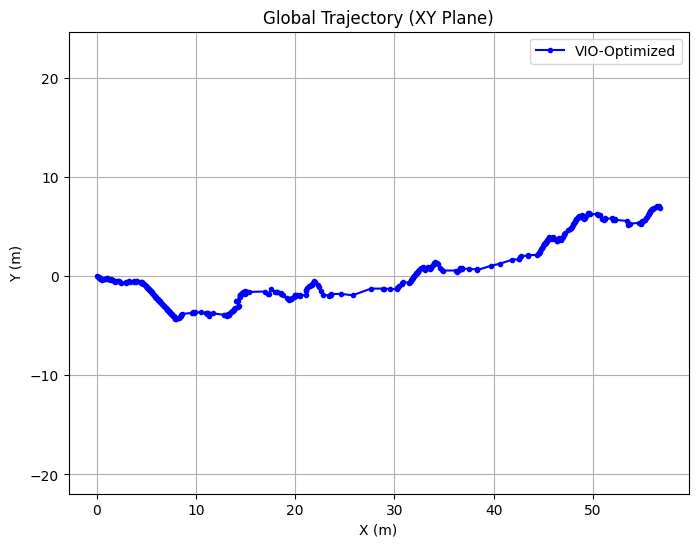

In [ ]:

"""
VIO-SLAM Simulated Pipeline with Downsampling and Smaller Window
================================================================

Includes:
 1. EuRoC data loading (images + IMU CSV)
 2. IMU preintegration module
 3. ORB feature + visual direction factor calculation
 4. Visual-inertial sliding window optimization
 5. Sliding window loop (frame skipping, reduced window size, optional multi-threading, progress bar)
 6. Global trajectory accumulation and visualization

"""

import os
import glob
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
from tqdm.std import tqdm
from multiprocessing import Pool

# -----------------------------------------------------------------------------
# 1. EuRoC Data Loader
# -----------------------------------------------------------------------------
class EuRoCDatasetLoader:
    def __init__(self, root_dir: str):
        self.root_dir = root_dir
        self.cam_dirs = {
            'cam0': os.path.join(root_dir, 'cam0', 'data'),
            'cam1': os.path.join(root_dir, 'cam1', 'data'),
        }
        self.imu_file = os.path.join(root_dir, 'imu0', 'data.csv')

    def load_images(self, cam: str = 'cam0'):
        cam_dir = self.cam_dirs.get(cam)
        if not cam_dir or not os.path.isdir(cam_dir):
            raise ValueError(f"Camera directory not found: {cam_dir}")
        files = sorted(glob.glob(os.path.join(cam_dir, '*.png')))
        timestamps = np.array([
            int(os.path.splitext(os.path.basename(f))[0]) for f in files
        ], dtype=np.int64)
        return timestamps, files

    def load_imu(self):
        if not os.path.isfile(self.imu_file):
            raise FileNotFoundError(f"IMU file not found: {self.imu_file}")
        data = np.loadtxt(self.imu_file, delimiter=',', comments='#')
        ts    = data[:, 0].astype(np.int64)
        gyro  = data[:, 1:4]
        accel = data[:, 4:7]
        return ts, gyro, accel

# -----------------------------------------------------------------------------
# 2. IMU Preintegration
# -----------------------------------------------------------------------------
class IMUPreintegrator:
    def __init__(self):
        self.reset()
    def reset(self):
        self.delta_t = 0.0
        self.delta_R = np.eye(3)
        self.delta_v = np.zeros(3)
        self.delta_p = np.zeros(3)
    def integrate(self, dt_arr, omega_arr, acc_arr, g=np.array([0,0,-9.81])):
        self.reset()
        for dt, w, a in zip(dt_arr, omega_arr, acc_arr):
            dR = Rotation.from_rotvec(w * dt).as_matrix()
            self.delta_R = self.delta_R @ dR
            a_w = self.delta_R @ a + g
            self.delta_v += a_w * dt
            self.delta_p += self.delta_v * dt + 0.5 * a_w * dt**2
            self.delta_t += dt
        return self.delta_p.copy(), self.delta_v.copy(), self.delta_R.copy()

# -----------------------------------------------------------------------------
# 3. Visual Factor (Essential + recoverPose)
# -----------------------------------------------------------------------------
def compute_visual_measurements(img_paths, K, cam_mat, num_matches=500):
    orb = cv2.ORB_create(nfeatures=1000)
    bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    R_vis, t_vis = [], []
    for i in range(K):
        img1 = cv2.imread(img_paths[i],   cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(img_paths[i+1], cv2.IMREAD_GRAYSCALE)
        kp1, des1 = orb.detectAndCompute(img1, None)
        kp2, des2 = orb.detectAndCompute(img2, None)
        matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)[:num_matches]
        pts1 = np.array([kp1[m.queryIdx].pt for m in matches])
        pts2 = np.array([kp2[m.trainIdx].pt for m in matches])
        E, _ = cv2.findEssentialMat(pts1, pts2, cam_mat,
                                     method=cv2.RANSAC, prob=0.999, threshold=1.0)
        _, R, t, _ = cv2.recoverPose(E, pts1, pts2, cam_mat)
        R_vis.append(R)
        t_vis.append(t.flatten())
    return R_vis, t_vis

# -----------------------------------------------------------------------------
# 4. Sliding Window VIO Optimization
# -----------------------------------------------------------------------------
def slide_window_vio(ts_img, ts_imu, gyro, accel, img_paths, cam_mat, K=3):
    # 4.1 IMU Preintegration
    preint = IMUPreintegrator()
    dps, dRs = [], []
    for i in range(1, K+1):
        t0, t1 = ts_img[i-1], ts_img[i]
        mask = (ts_imu >= t0) & (ts_imu < t1)
        ts_sec    = ts_imu[mask] * 1e-9
        dt_arr    = np.diff(ts_sec)
        omega_arr = gyro[mask][:-1]
        acc_arr   = accel[mask][:-1]
        dp, dv, dR = preint.integrate(dt_arr, omega_arr, acc_arr)
        dps.append(dp); dRs.append(dR)
    # 4.2 Visual Direction Factor
    R_vis, t_vis = compute_visual_measurements(img_paths, K, cam_mat)
    t_dirs = [t/np.linalg.norm(t) for t in t_vis]
    # 4.3 Initial Guess
    p_init = np.zeros((K+1,3))
    theta  = np.zeros(K+1)
    for i in range(1, K+1):
        p_init[i] = p_init[i-1] + dps[i-1]
        yaw = np.arctan2(dRs[i-1][1,0], dRs[i-1][0,0])
        theta[i] = theta[i-1] + yaw
    x0 = np.hstack([p_init.flatten(), theta])
    # 4.4 Define Residuals
    def residual(x):
        p = x[:3*(K+1)].reshape((K+1,3))
        th = x[3*(K+1):]
        res = []
        for i in range(1, K+1):
            # IMU Translation
            res.extend((p[i]-p[i-1]-dps[i-1]).tolist())
            # IMU Yaw
            dy = th[i]-th[i-1]
            yaw_m = np.arctan2(dRs[i-1][1,0], dRs[i-1][0,0])
            res.append(dy - yaw_m)
            # Visual Direction
            dp_est = p[i]-p[i-1]
            dir_est = dp_est/(np.linalg.norm(dp_est)+1e-8)
            res.extend((dir_est - t_dirs[i-1]).tolist())
        return np.array(res)
    sol = least_squares(residual, x0, verbose=0)
    p_opt = sol.x[:3*(K+1)].reshape((K+1,3))
    return p_init, p_opt

# -----------------------------------------------------------------------------
# 5. Main Pipeline
# -----------------------------------------------------------------------------
def main():
    # Data Loading
    loader = EuRoCDatasetLoader('data/mav0')
    ts_img, img_paths = loader.load_images('cam0')
    ts_imu, gyro, accel = loader.load_imu()
    # Camera Intrinsics
    cam_mat = np.array([[458.654, 0.0, 367.215],
                        [0.0, 457.296, 248.375],
                        [0.0, 0.0, 1.0]])
    # Parameters: Frame Skipping + Window
    downsample  = 10   # Run every 10 frames
    window_size = 3    # Window length = 4 frames
    num_windows = len(ts_img) - window_size
    starts = list(range(0, num_windows, downsample))
    # Sliding Window Loop
    traj_opt = []
    start_time = time.time()
    for s in tqdm(starts, desc="VIO Sliding-Window", ncols=80):
        t_win   = ts_img[s:s+window_size+1]
        img_win = img_paths[s:s+window_size+1]
        _, p_opt = slide_window_vio(
            t_win, ts_imu, gyro, accel,
            img_win, cam_mat, K=window_size
        )
        traj_opt.append(p_opt[-1])
    elapsed = time.time() - start_time
    print(f"\nTotal time: {elapsed:.2f}s for {len(starts)} windows")
    print(f"Avg per window: {elapsed/len(starts)*1000:.3f} ms")
    # Global Trajectory Accumulation
    traj_opt = np.array(traj_opt)
    traj_global = np.vstack(([0,0,0], np.cumsum(traj_opt, axis=0)))
    # Visualization
    plt.figure(figsize=(8,6))
    plt.plot(traj_global[:,0], traj_global[:,1], 'b.-', label='VIO-Optimized')
    plt.title('Global Trajectory (XY Plane)')
    plt.xlabel('X (m)'); plt.ylabel('Y (m)')
    plt.axis('equal'); plt.grid(True); plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
